In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [128]:
class my_lr:
    def __init__(self):
        self.m=None
        self.c=None
    def train(self,x,y):
        xbar=x.mean()
        ybar=y.mean()
        num=0
        den=0
        for i in range(x.size):
            num=num+((y[i]-ybar)*(x[i]-xbar))
            den=den+((x[i]-xbar)*(x[i]-xbar))
        self.m=num/den
        self.c=ybar-(self.m*xbar)
    def predict(self,x):
        return (self.m*x)+self.c

In [129]:
data=pd.read_csv('datasets/Student_Marks.csv')
data

,number_courses,time_study,Marks
0,3,4.508,19.202
1,4,0.096,7.734
2,4,3.133,13.811
3,6,7.909,53.018
4,8,7.811,55.299
...,...,...,...
95,6,3.561,19.128
96,3,0.301,5.609
97,4,7.163,41.444
98,7,0.309,12.027


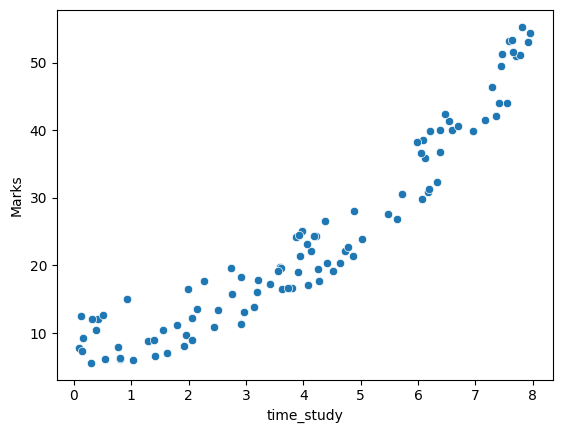

In [130]:
sns.scatterplot(data=data,x='time_study',y='Marks')
plt.show()

In [131]:
x=np.array(data['time_study'])
y=np.array(data['Marks'])

In [132]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [133]:
model=my_lr()
model.train(x_train,y_train)

In [134]:
y_test_predicted=np.arange(0,y_test.size)

In [135]:
for i in range(y_test.size):
    y_test_predicted[i]=model.predict(x_test[i])

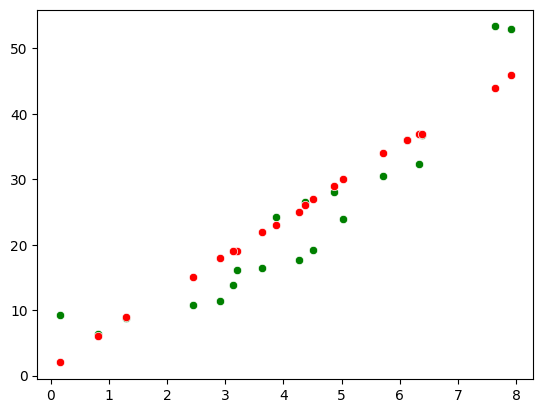

In [136]:
sns.scatterplot(x=x_test,y=y_test,color='g')
sns.scatterplot(x=np.array(x_test),y=np.array(y_test_predicted),color='r')
plt.show()

In [137]:
model2=LinearRegression()
model2.fit(x_train.reshape(-1,1),y_train.reshape(-1,1))

LinearRegression()

In [138]:
model2.predict(x_test.reshape(-1,1))

array([[19.83510323],
       [23.60114303],
       [44.92697862],
       [22.30815485],
       [34.0749119 ],
       [29.30948822],
       [19.47374409],
       [26.50330864],
       [ 2.66489777],
       [25.91610003],
       [37.55299364],
       [30.16771618],
       [37.80142805],
       [18.20334086],
       [27.23731939],
       [36.37293019],
       [46.44017003],
       [ 9.11854619],
       [15.54960966],
       [ 6.32930531]])

In [139]:
y_test_predicted

array([19, 23, 44, 22, 34, 29, 19, 26,  2, 25, 37, 30, 37, 18, 27, 36, 46,
        9, 15,  6])

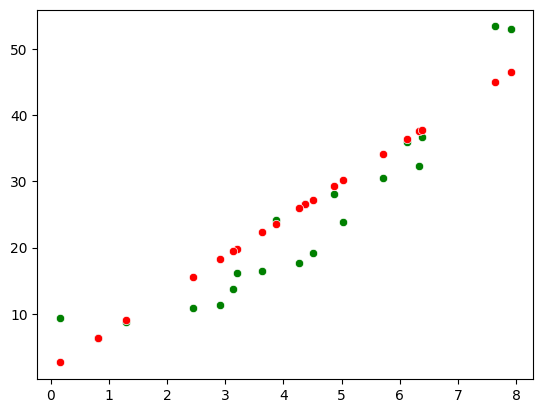

In [127]:
l=list(model2.predict(x_test.reshape(-1,1)))
l=[float(i[0]) for i in l]
sns.scatterplot(x=x_test,y=y_test,color='g')
sns.scatterplot(x=x_test,y=l,color='r')
plt.show()